In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

import sys
sys.path.append("../src")
from preprocessing import pipeline_completo

df = pipeline_completo("../data/raw/telco_churn.csv")

print(f"Dados pré-processados: {df.shape[0]} linhas e {df.shape[1]} colunas")
df.info()

Dados pré-processados: 7043 linhas e 31 colunas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   Churn                                  7043 non-null   int64  
 5   gender_Male                            7043 non-null   int64  
 6   Partner_Yes                            7043 non-null   int64  
 7   Dependents_Yes                         7043 non-null   int64  
 8   PhoneService_Yes                       7043 non-null   int64  
 9   MultipleLines_No phone service         7043 non-null   int64  
 10  MultipleLines_Yes       

In [37]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_treino,X_teste,y_treino,y_teste = train_test_split(X,y, test_size=0.3, random_state=42, stratify=y)

print(f"Treino: {X_treino.shape[0]} instâncias")
print(f"Teste:  {X_teste.shape[0]} instâncias")
print(f"\nProporção de churn no treino:")
print(y_treino.value_counts(normalize=True).round(3))
print(f"\nProporção de churn no teste:")
print(y_teste.value_counts(normalize=True).round(3))



Treino: 4930 instâncias
Teste:  2113 instâncias

Proporção de churn no treino:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

Proporção de churn no teste:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


In [38]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

modelos = {
    "Naive Bayes": GaussianNB(),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100)
}

for nome, modelo in modelos.items():
    modelo.fit(X_treino,y_treino)
    print(f'{nome} treinado')


Naive Bayes treinado
Árvore de Decisão treinado
Random Forest treinado


In [39]:
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                               f1_score, confusion_matrix, classification_report)

resultados = {}

for nome, modelo in modelos.items():

    y_pred = modelo.predict(X_teste)

    resultados[nome] = {
        "Acurácia":  accuracy_score(y_teste, y_pred),
        "Recall":    recall_score(y_teste, y_pred),
        "Precisão":  precision_score(y_teste, y_pred),
        "F1-Score":  f1_score(y_teste, y_pred),
    }

df_resultados = pd.DataFrame(resultados).T 
df_resultados = df_resultados.round(4) 
print("\nComparação dos Modelos (SEM SMOTE):\n")
print(df_resultados.to_string())


Comparação dos Modelos (SEM SMOTE):

                   Acurácia  Recall  Precisão  F1-Score
Naive Bayes          0.6507  0.8717    0.4234    0.5699
Árvore de Decisão    0.7880  0.5169    0.6210    0.5642
Random Forest        0.7889  0.4973    0.6298    0.5558


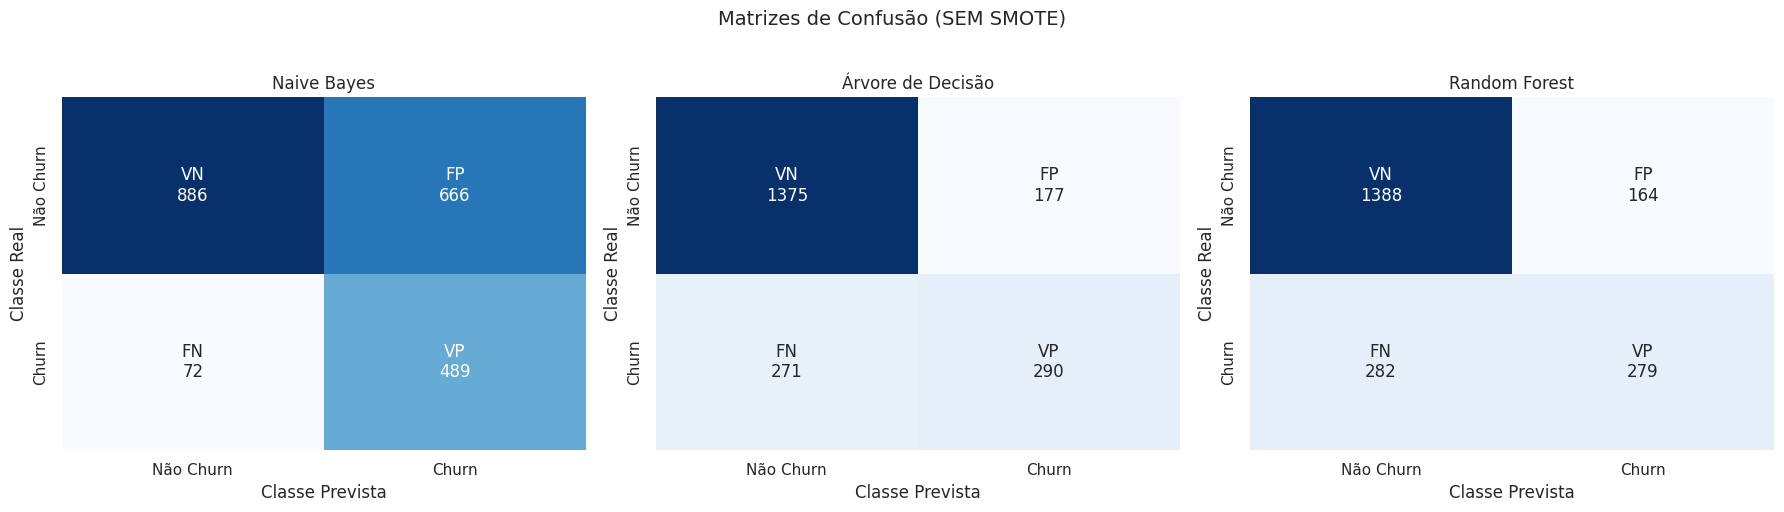

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (nome, modelo) in enumerate(modelos.items()):
    y_pred = modelo.predict(X_teste)
    cm = confusion_matrix(y_teste, y_pred)
    
    labels = [
        [f"VN\n{cm[0,0]}", f"FP\n{cm[0,1]}"],
        [f"FN\n{cm[1,0]}", f"VP\n{cm[1,1]}"]
    ]
    labels = np.array(labels)

    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False,
                xticklabels=["Não Churn", "Churn"],
                yticklabels=["Não Churn", "Churn"], ax=axes[i])
    axes[i].set_title(f"{nome}")
    axes[i].set_ylabel("Classe Real")
    axes[i].set_xlabel("Classe Prevista")

plt.suptitle("Matrizes de Confusão (SEM SMOTE)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

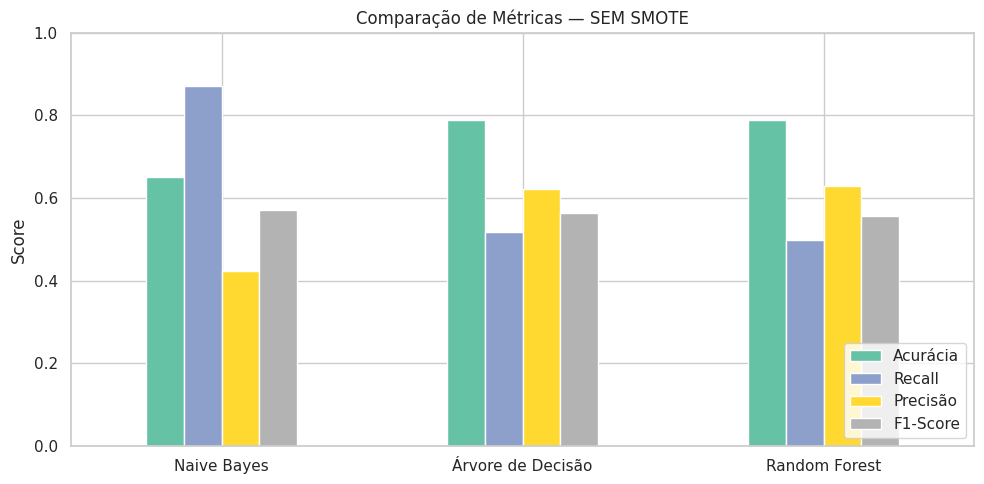

In [15]:
df_resultados.plot(kind="bar", figsize=(10, 5), rot=0, colormap="Set2")
plt.title("Comparação de Métricas — SEM SMOTE")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE

print("Proporção ANTES do SMOTE:")
print(y_treino.value_counts())
print()

smote = SMOTE(random_state=42)
X_treino_smote, y_treino_smote = smote.fit_resample(X_treino, y_treino)

print("Proporção DEPOIS do SMOTE:")
print(pd.Series(y_treino_smote).value_counts())

Proporção ANTES do SMOTE:
Churn
0    3622
1    1308
Name: count, dtype: int64

Proporção DEPOIS do SMOTE:
Churn
0    3622
1    3622
Name: count, dtype: int64


In [40]:
modelos_smote = {
    "Naive Bayes": GaussianNB(),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200)
}

resultados_smote = {}

for nome, modelo in modelos_smote.items():
    modelo.fit(X_treino_smote, y_treino_smote)

    y_pred = modelo.predict(X_teste)

    resultados_smote[nome] = {
        "Acurácia":  accuracy_score(y_teste, y_pred),
        "Recall":    recall_score(y_teste, y_pred),
        "Precisão":  precision_score(y_teste, y_pred),
        "F1-Score":  f1_score(y_teste, y_pred),
    }

df_resultados_smote = pd.DataFrame(resultados_smote).T.round(4)

print("\nComparação dos Modelos (COM SMOTE):\n")
print(df_resultados_smote.to_string())


Comparação dos Modelos (COM SMOTE):

                   Acurácia  Recall  Precisão  F1-Score
Naive Bayes          0.7104  0.8021    0.4732    0.5952
Árvore de Decisão    0.7421  0.6667    0.5109    0.5785
Random Forest        0.7757  0.6096    0.5729    0.5907


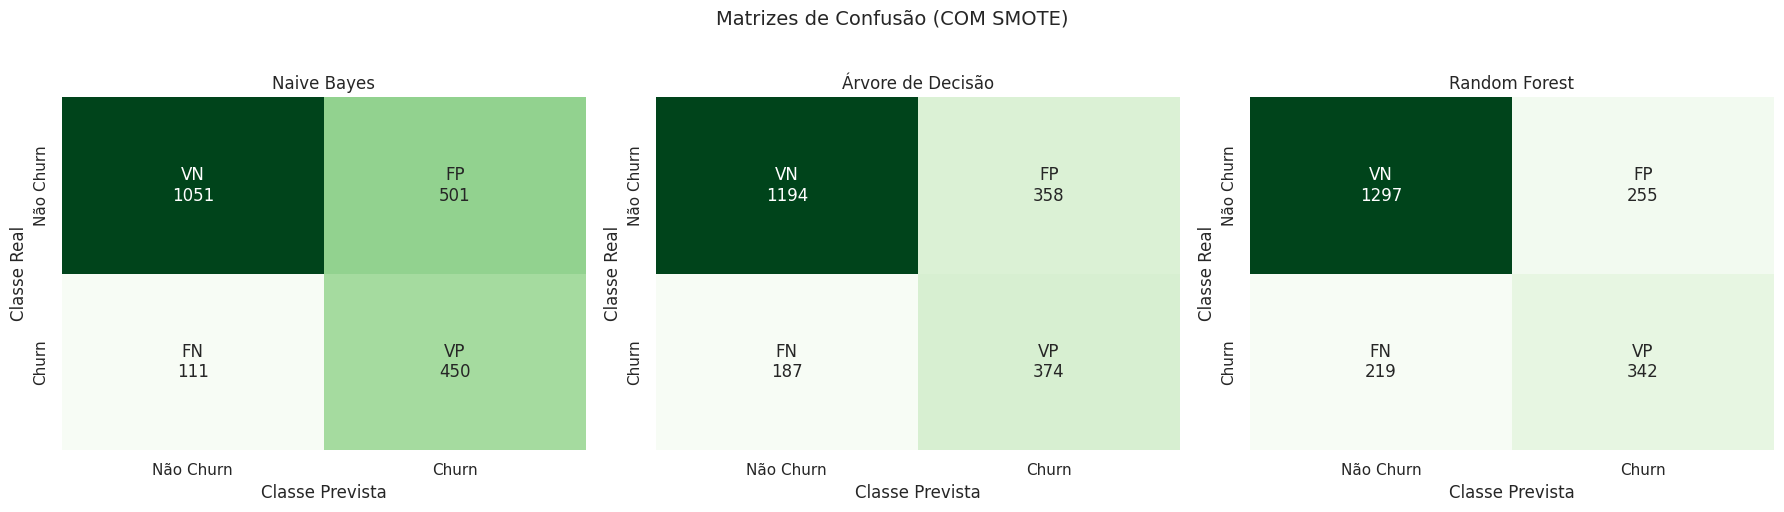

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (nome, modelo) in enumerate(modelos_smote.items()):
    y_pred = modelo.predict(X_teste)
    cm = confusion_matrix(y_teste, y_pred)

    labels = [
        [f"VN\n{cm[0,0]}", f"FP\n{cm[0,1]}"],
        [f"FN\n{cm[1,0]}", f"VP\n{cm[1,1]}"]
    ]
    labels = np.array(labels)

    sns.heatmap(cm, annot=labels, fmt="", cmap="Greens", cbar=False,
                xticklabels=["Não Churn", "Churn"],
                yticklabels=["Não Churn", "Churn"], ax=axes[i])
    axes[i].set_title(f"{nome}")
    axes[i].set_ylabel("Classe Real")
    axes[i].set_xlabel("Classe Prevista")

plt.suptitle("Matrizes de Confusão (COM SMOTE)", fontsize=14, y=1.02)
plt.tight_layout()

In [41]:

CUSTO_FN = 1500
CUSTO_FP = 100 

def calcular_custo(nome_modelo, modelo, X_teste, y_teste):
    
    y_pred = modelo.predict(X_teste)
    cm = confusion_matrix(y_teste, y_pred)

    # cm[0,0] = VN, cm[0,1] = FP, cm[1,0] = FN, cm[1,1] = VP
    fn = cm[1, 0]
    fp = cm[0, 1]

    custo_fn = fn * CUSTO_FN
    custo_fp = fp * CUSTO_FP
    custo_total = custo_fn + custo_fp

    return {
        "Modelo": nome_modelo,
        "FN (clientes perdidos)": fn,
        "FP (ações desnecessárias)": fp,
        "Custo FN (R$)": custo_fn,
        "Custo FP (R$)": custo_fp,
        "Custo Total (R$)": custo_total
    }

custos = []
for nome, modelo in modelos_smote.items():
    custos.append(calcular_custo(nome, modelo, X_teste, y_teste))

df_custos = pd.DataFrame(custos).set_index("Modelo")
print("\nAnálise de Custo dos Modelos:\n")
print(df_custos.to_string())


Análise de Custo dos Modelos:

                   FN (clientes perdidos)  FP (ações desnecessárias)  Custo FN (R$)  Custo FP (R$)  Custo Total (R$)
Modelo                                                                                                              
Naive Bayes                           111                        501         166500          50100            216600
Árvore de Decisão                     187                        358         280500          35800            316300
Random Forest                         219                        255         328500          25500            354000


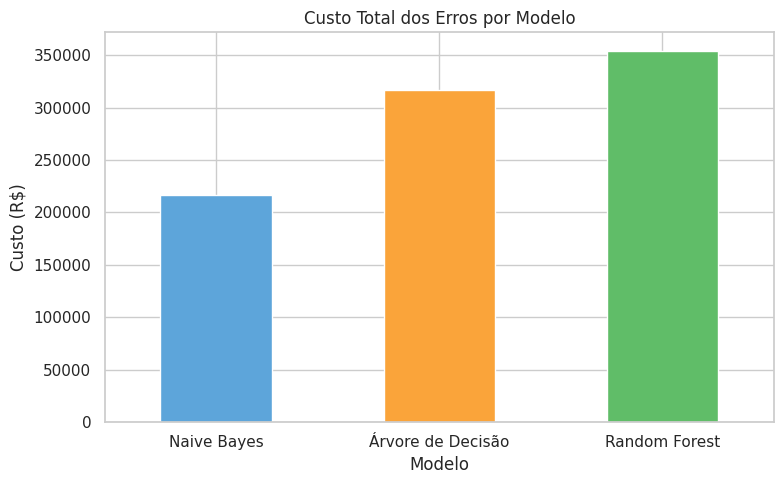

In [42]:
df_custos["Custo Total (R$)"].plot(kind="bar", figsize=(8, 5), color=["#5da5da", "#faa43a", "#60bd68"], rot=0)
plt.title("Custo Total dos Erros por Modelo")
plt.ylabel("Custo (R$)")
plt.tight_layout()
plt.show()

In [43]:
total_churn_real = y_teste.sum()

custo_sem_modelo = total_churn_real * CUSTO_FN
melhor_modelo_nome = df_custos["Custo Total (R$)"].idxmin()
melhor_custo = df_custos["Custo Total (R$)"].min()
economia = custo_sem_modelo - melhor_custo

print(f"\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"  Cenário SEM modelo:")
print(f"    Todos os {total_churn_real} churns passam despercebidos.")
print(f"    Custo: {total_churn_real} × R$ {CUSTO_FN} = R$ {custo_sem_modelo:,.2f}")
print(f"")
print(f"  Cenário COM o melhor modelo ({melhor_modelo_nome}):")
print(f"    Custo dos erros: R$ {melhor_custo:,.2f}")
print(f"")
print(f"  ECONOMIA ESTIMADA: R$ {economia:,.2f}")
print(f"     ({(economia/custo_sem_modelo*100):.1f}% de redução nas perdas)")
print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Cenário SEM modelo:
    Todos os 561 churns passam despercebidos.
    Custo: 561 × R$ 1500 = R$ 841,500.00

  Cenário COM o melhor modelo (Naive Bayes):
    Custo dos erros: R$ 216,600.00

  ECONOMIA ESTIMADA: R$ 624,900.00
     (74.3% de redução nas perdas)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
